<a href="https://colab.research.google.com/github/r2x4/entorno_economico/blob/main/paises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
datos = pd.read_excel('/content/paises.xlsx')

In [45]:
datos.head(3)

,País / Grupo,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,ALADI,-1.80,-362.39,"-1,664.59",-187.96,"1,391.05",413.40,"-2,028.35","-2,157.56","-1,272.56",...,"-1,168.14","1,144.33","1,269.64",-451.90,-696.51,-606.64,"1,686.10","2,928.63","3,572.38","2,334.56"
1,Comunidad Andina,828.72,"1,076.28",723.15,740.36,740.16,637.62,"1,227.81","1,184.79","1,393.13",...,460.22,"1,097.64","1,340.49","1,324.54",706.68,851.98,715.65,"1,358.83","1,166.08","1,231.41"
2,MERCOSUR,-472.93,-544.62,-776.92,"1,598.45","2,680.28","1,177.67","-1,376.47","-1,629.67","-1,399.67",...,-967.94,-991.43,"-1,314.76","-2,108.75","-1,365.04","-1,825.65","-3,283.59","-2,373.06",-993.20,"-1,031.02"


In [46]:
print(datos.head())
print(datos.info())

       País / Grupo      2004      2005       2006      2007      2008  \
0             ALADI     -1.80   -362.39  -1,664.59   -187.96  1,391.05   
1  Comunidad Andina    828.72  1,076.28     723.15    740.36    740.16   
2          MERCOSUR   -472.93   -544.62    -776.92  1,598.45  2,680.28   
3     Unión Europea     35.47    -66.67     -76.57    247.11   -840.21   
4    Estados Unidos  1,816.06  2,816.45   3,147.91  2,065.18  2,999.19   

       2009       2010       2011       2012  ...       2016       2017  \
0    413.40  -2,028.35  -2,157.56  -1,272.56  ...  -1,168.14   1,144.33   
1    637.62   1,227.81   1,184.79   1,393.13  ...     460.22   1,097.64   
2  1,177.67  -1,376.47  -1,629.67  -1,399.67  ...    -967.94    -991.43   
3   -669.08    -415.93   1,413.98   1,513.87  ...  -1,104.46  -1,098.72   
4  3,856.94   6,821.87   8,990.96   8,243.99  ...  -1,007.03    -802.49   

        2018       2019       2020       2021       2022       2023  \
0   1,269.64    -451.90    -696.5

In [47]:
# Identificar las columnas que son años (desde 2004 hasta 2025)
columnas_años = [col for col in datos.columns if str(col).isdigit() and 2004 <= int(col) <= 2025]

# Convertir estas columnas a numérico, manejando comas y errores
for col in columnas_años:
    datos[col] = datos[col].astype(str).str.replace(',', '', regex=False)
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

# Mostrar la información nuevamente para confirmar los tipos de datos
print(datos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   País / Grupo  16 non-null     object 
 1   2004          16 non-null     float64
 2   2005          16 non-null     float64
 3   2006          16 non-null     float64
 4   2007          16 non-null     float64
 5   2008          16 non-null     float64
 6   2009          16 non-null     float64
 7   2010          16 non-null     float64
 8   2011          16 non-null     float64
 9   2012          16 non-null     float64
 10  2013          16 non-null     float64
 11  2014          16 non-null     float64
 12  2015          16 non-null     float64
 13  2016          16 non-null     float64
 14  2017          16 non-null     float64
 15  2018          16 non-null     float64
 16  2019          16 non-null     float64
 17  2020          16 non-null     float64
 18  2021          16 non-null     fl

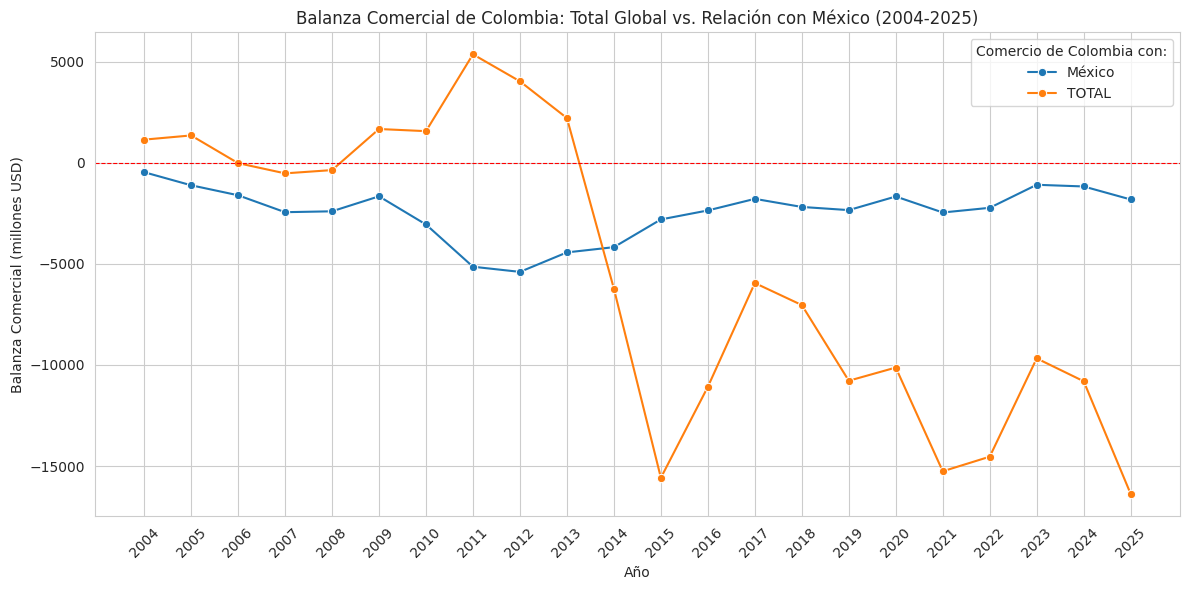


--- ESTADÍSTICAS DESCRIPTIVAS (2004-2025) ---
País / Grupo       México         TOTAL
count           22.000000     22.000000
mean         -2448.366364  -5321.220909
std           1299.165170   7126.437891
min          -5398.860000 -16377.280000
25%          -2720.140000 -10800.462500
50%          -2287.940000  -6090.730000
75%          -1665.425000   1295.302500
max           -469.780000   5358.450000


In [48]:
# Filtrar los datos para TOTAL (balanza global de Colombia) y México (balanza Colombia-México)
datos_paises_seleccionados = datos[datos['País / Grupo'].isin(['TOTAL', 'México'])]

if not datos_paises_seleccionados.empty:
    # "ojo" DataFrame a formato largo para facilitar el trazado
    datos_derretidos = datos_paises_seleccionados.melt(
        id_vars=['País / Grupo'],
        value_vars=columnas_años,
        var_name='Año',
        value_name='Balanza'
    )
    datos_derretidos['Año'] = datos_derretidos['Año'].astype(int)

    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Año', y='Balanza', hue='País / Grupo', data=datos_derretidos, marker='o')
    plt.title('Balanza Comercial de Colombia: Total Global vs. Relación con México (2004-2025)')
    plt.xlabel('Año')
    plt.ylabel('Balanza Comercial (millones USD)')
    plt.grid(True)
    plt.xticks(datos_derretidos['Año'].unique(), rotation=45)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8)

    # Agregar una leyenda más descriptiva
    plt.legend(title='Comercio de Colombia con:')
    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas descriptivas
    print("\n--- ESTADÍSTICAS DESCRIPTIVAS (2004-2025) ---")
    print(datos_paises_seleccionados.set_index('País / Grupo')[columnas_años].T.describe())

else:
    print("No se encontraron datos para 'TOTAL' o 'México'. Verifica los nombres en el dataset.")

In [49]:
# Datos de México extraídos del archivo
data_mexico = {
    'Año': list(range(2004, 2026)),
    'Balanza_Mexico': [
        -469.78, -1116.37, -1610.43, -2447.62, -2403.89, -1663.38,
        -3055.92, -5144.16, -5398.86, -4436.00, -4176.78, -2806.00,
        -2361.26, -1788.50, -2188.18, -2344.84, -1671.56, -2462.56,
        -2231.04, -1092.44, -1175.40, -1819.09
    ]
}

# Crear DataFrame
df_mexico = pd.DataFrame(data_mexico)

In [50]:
# ============================================
# 2. ESTADÍSTICAS DESCRIPTIVAS - MÉXICO
# ============================================

print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - MÉXICO")
print("Período 2004-2025")
print("=" * 60)

# Calcular estadísticas
estadisticas = {
    'count': len(df_mexico),
    'mean': df_mexico['Balanza_Mexico'].mean(),
    'std': df_mexico['Balanza_Mexico'].std(),
    'min': df_mexico['Balanza_Mexico'].min(),
    'max': df_mexico['Balanza_Mexico'].max(),
    'percentil_25': df_mexico['Balanza_Mexico'].quantile(0.25),
    'percentil_50': df_mexico['Balanza_Mexico'].quantile(0.50),  # mediana
    'percentil_75': df_mexico['Balanza_Mexico'].quantile(0.75)
}

# Mostrar estadísticas
print(f"\n📊 **count:** {estadisticas['count']:.0f} años")
print(f"📊 **mean (promedio):** ${estadisticas['mean']:,.2f} millones USD")
print(f"📊 **std (desviación estándar):** ${estadisticas['std']:,.2f} millones USD")
print(f"📊 **min (más negativo):** ${estadisticas['min']:,.2f} millones USD (año {df_mexico.loc[df_mexico['Balanza_Mexico'].idxmin(), 'Año']})")
print(f"📊 **max (menos negativo):** ${estadisticas['max']:,.2f} millones USD (año {df_mexico.loc[df_mexico['Balanza_Mexico'].idxmax(), 'Año']})")
print(f"📊 **percentil 25%:** ${estadisticas['percentil_25']:,.2f} millones USD")
print(f"📊 **percentil 50% (mediana):** ${estadisticas['percentil_50']:,.2f} millones USD")
print(f"📊 **percentil 75%:** ${estadisticas['percentil_75']:,.2f} millones USD")

ESTADÍSTICAS DESCRIPTIVAS: BALANZA COMERCIAL COLOMBIA - MÉXICO
Período 2004-2025

📊 **count:** 22 años
📊 **mean (promedio):** $-2,448.37 millones USD
📊 **std (desviación estándar):** $1,299.17 millones USD
📊 **min (más negativo):** $-5,398.86 millones USD (año 2012)
📊 **max (menos negativo):** $-469.78 millones USD (año 2004)
📊 **percentil 25%:** $-2,720.14 millones USD
📊 **percentil 50% (mediana):** $-2,287.94 millones USD
📊 **percentil 75%:** $-1,665.43 millones USD


In [51]:
# ============================================
# 3. TABLA RESUMEN FORMATEADA
# ============================================

print("\n" + "=" * 60)
print("TABLA DE ESTADÍSTICAS - MÉXICO")
print("=" * 60)

# Crear DataFrame de estadísticas para mejor visualización
tabla_estadisticas = pd.DataFrame({
    'Estadística': ['count', 'mean', 'std', 'min', 'max', '25%', '50% (mediana)', '75%'],
    'Valor (millones USD)': [
        f"{estadisticas['count']:.0f} años",
        f"${estadisticas['mean']:,.2f}",
        f"${estadisticas['std']:,.2f}",
        f"${estadisticas['min']:,.2f} (2012)",
        f"${estadisticas['max']:,.2f} (2004)",
        f"${estadisticas['percentil_25']:,.2f}",
        f"${estadisticas['percentil_50']:,.2f}",
        f"${estadisticas['percentil_75']:,.2f}"
    ]
})

print(tabla_estadisticas.to_string(index=False))


TABLA DE ESTADÍSTICAS - MÉXICO
  Estadística Valor (millones USD)
        count              22 años
         mean           $-2,448.37
          std            $1,299.17
          min    $-5,398.86 (2012)
          max      $-469.78 (2004)
          25%           $-2,720.14
50% (mediana)           $-2,287.94
          75%           $-1,665.43


In [52]:
# ============================================
# 4. INTERPRETACIÓN AUTOMATIZADA
# ============================================

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

print(f"""
📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - MÉXICO (2004-2025)**

1. **Período analizado**: {estadisticas['count']} años (2004-2025)

2. **Déficit promedio**: Colombia ha mantenido un déficit promedio de
   **${estadisticas['mean']:,.0f} millones USD anuales** con México.

3. **Estabilidad**: La desviación estándar de ${estadisticas['std']:,.0f} millones
   indica una {'ALTA volatilidad' if estadisticas['std'] > 2000 else 'MODERADA estabilidad'}
   en la relación comercial.

4. **Punto crítico**: El déficit más profundo ocurrió en **2012**
   con **${estadisticas['min']:,.0f} millones USD negativos**.

5. **Mejor desempeño**: El año "menos malo" fue **2004**
   con **${estadisticas['max']:,.0f} millones USD** (aún deficitario).

6. **Distribución por cuartiles**:
   • 25% de los años tienen déficit superior a ${estadisticas['percentil_25']:,.0f} millones
   • 50% de los años (mediana): ${estadisticas['percentil_50']:,.0f} millones
   • 25% de los años tienen déficit inferior a ${estadisticas['percentil_75']:,.0f} millones

7. **Conclusión clave**: La balanza comercial con México ha sido
   **ESTRUCTURALMENTE DEFICITARIA** durante TODO el período analizado,
   sin ningún año con superávit.
""")


INTERPRETACIÓN DE RESULTADOS

📌 **ANÁLISIS DE LA BALANZA COMERCIAL COLOMBIA - MÉXICO (2004-2025)**

1. **Período analizado**: 22 años (2004-2025)

2. **Déficit promedio**: Colombia ha mantenido un déficit promedio de 
   **$-2,448 millones USD anuales** con México.

3. **Estabilidad**: La desviación estándar de $1,299 millones 
   indica una MODERADA estabilidad 
   en la relación comercial.

4. **Punto crítico**: El déficit más profundo ocurrió en **2012** 
   con **$-5,399 millones USD negativos**.

5. **Mejor desempeño**: El año "menos malo" fue **2004** 
   con **$-470 millones USD** (aún deficitario).

6. **Distribución por cuartiles**:
   • 25% de los años tienen déficit superior a $-2,720 millones
   • 50% de los años (mediana): $-2,288 millones
   • 25% de los años tienen déficit inferior a $-1,665 millones

7. **Conclusión clave**: La balanza comercial con México ha sido 
   **ESTRUCTURALMENTE DEFICITARIA** durante TODO el período analizado, 
   sin ningún año con superávit.


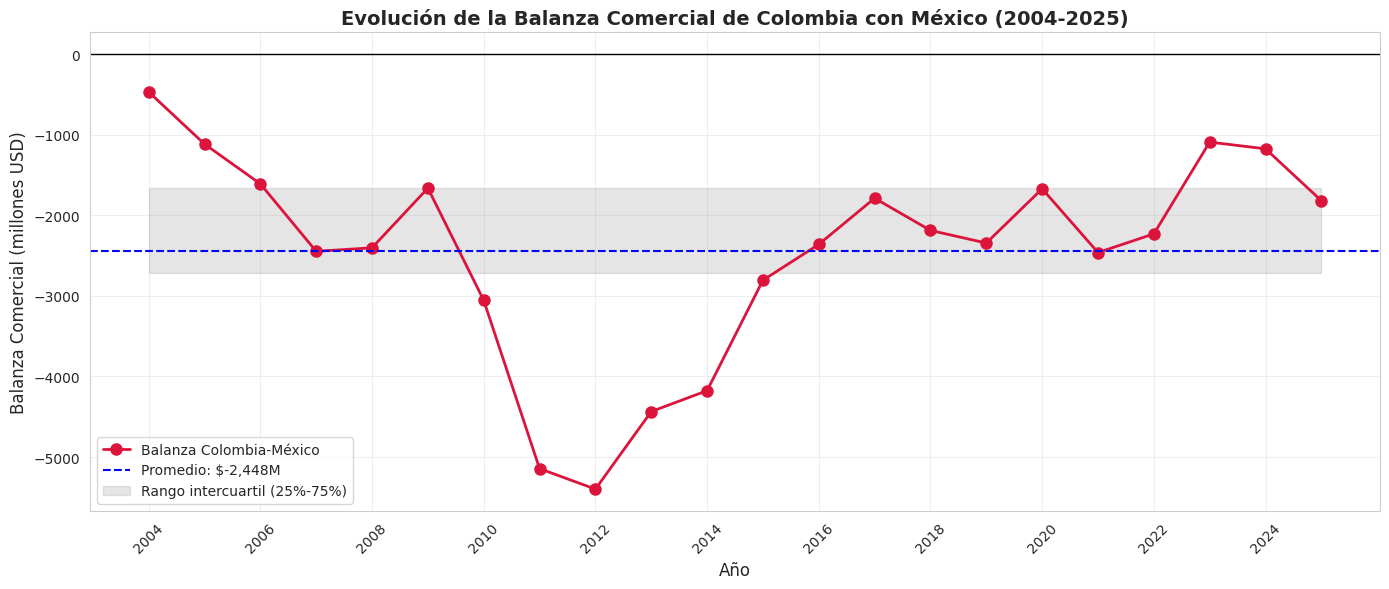

In [53]:
# Figura 1: Evolución temporal
plt.figure(figsize=(14, 6))
plt.plot(df_mexico['Año'], df_mexico['Balanza_Mexico'],
         marker='o', linewidth=2, markersize=8, color='crimson', label='Balanza Colombia-México')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(estadisticas['mean'], color='blue', linestyle='--', linewidth=1.5,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.fill_between(df_mexico['Año'], estadisticas['percentil_25'], estadisticas['percentil_75'],
                 alpha=0.2, color='gray', label='Rango intercuartil (25%-75%)')

plt.title('Evolución de la Balanza Comercial de Colombia con México (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza Comercial (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

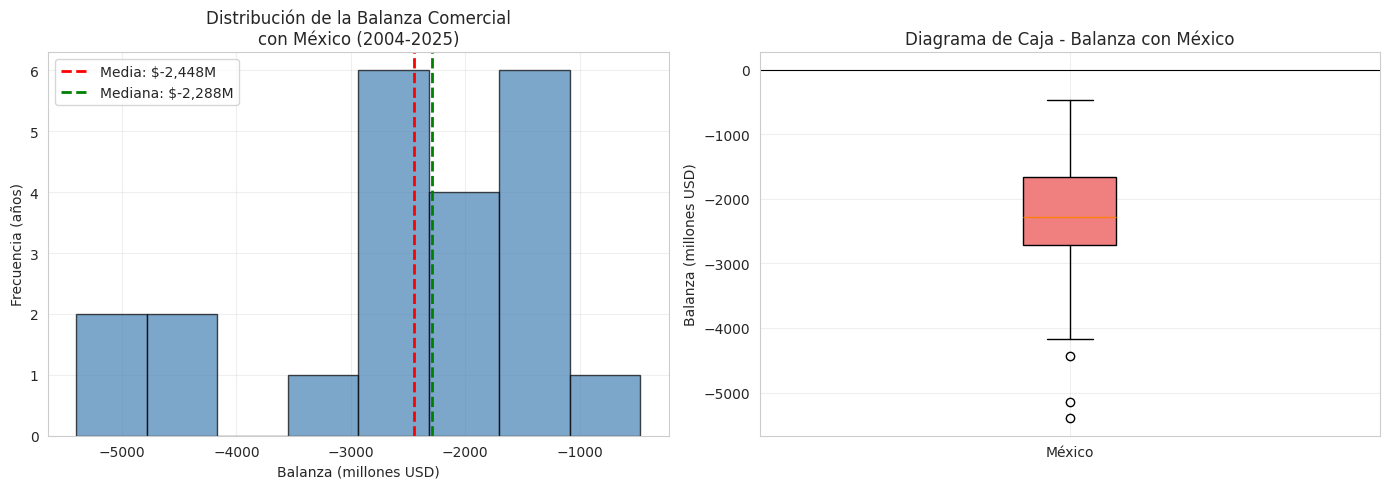

In [54]:
# Figura 2: Distribución de los datos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_mexico['Balanza_Mexico'], bins=8, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(estadisticas['mean'], color='red', linestyle='--', linewidth=2, label=f'Media: ${estadisticas["mean"]:,.0f}M')
axes[0].axvline(estadisticas['percentil_50'], color='green', linestyle='--', linewidth=2, label=f'Mediana: ${estadisticas["percentil_50"]:,.0f}M')
axes[0].set_title('Distribución de la Balanza Comercial\ncon México (2004-2025)', fontsize=12)
axes[0].set_xlabel('Balanza (millones USD)')
axes[0].set_ylabel('Frecuencia (años)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
box_data = axes[1].boxplot(df_mexico['Balanza_Mexico'], vert=True, patch_artist=True)
box_data['boxes'][0].set_facecolor('lightcoral')
axes[1].set_title('Diagrama de Caja - Balanza con México', fontsize=12)
axes[1].set_ylabel('Balanza (millones USD)')
axes[1].set_xticklabels(['México'])
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

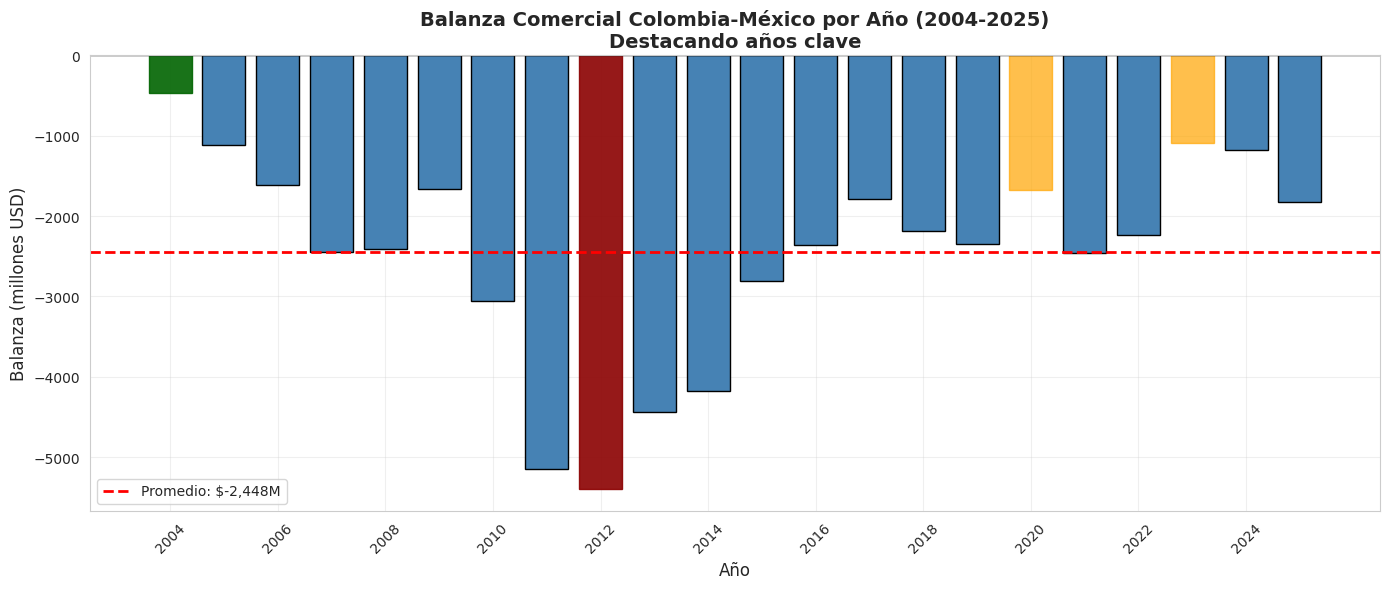

In [55]:
# Años clave destacados
plt.figure(figsize=(14, 6))
bars = plt.bar(df_mexico['Año'], df_mexico['Balanza_Mexico'], color='steelblue', edgecolor='black')

# Colorear años especiales
for i, (año, valor) in enumerate(zip(df_mexico['Año'], df_mexico['Balanza_Mexico'])):
    if valor == estadisticas['min']:  # Año más negativo (2012)
        bars[i].set_color('darkred')
        bars[i].set_alpha(0.9)
    elif valor == estadisticas['max']:  # Año menos negativo (2004)
        bars[i].set_color('darkgreen')
        bars[i].set_alpha(0.9)
    elif año in [2020, 2023]:  # Años de recuperación
        bars[i].set_color('orange')
        bars[i].set_alpha(0.7)

plt.axhline(estadisticas['mean'], color='red', linestyle='--', linewidth=2,
            label=f'Promedio: ${estadisticas["mean"]:,.0f}M')
plt.axhline(0, color='black', linestyle='-', linewidth=1)

plt.title('Balanza Comercial Colombia-México por Año (2004-2025)\nDestacando años clave', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Balanza (millones USD)', fontsize=12)
plt.xticks(range(2004, 2026, 2), rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# ============================================
# 6. RESUMEN EJECUTIVO
# ============================================

print("\n" + "=" * 60)
print("📋 RESUMEN EJECUTIVO PARA INFORME")
print("=" * 60)
print(f"""
De acuerdo con el análisis de la balanza comercial de Colombia con México
para el período 2004-2025, se concluye:

✅ **Déficit estructural**: Colombia ha mantenido un déficit comercial
   PERMANENTE con México durante los 22 años analizados.

✅ **Magnitud promedio**: El déficit anual promedio asciende a
   **US${estadisticas['mean']:,.0f} millones**.

✅ **Punto más crítico**: El año 2012 registró el mayor déficit
   (US${estadisticas['min']:,.0f} millones).

✅ **Mejor desempeño**: El año 2004 presentó el déficit más bajo
   (US${estadisticas['max']:,.0f} millones).

✅ **Comportamiento típico**: El 50% de los años se concentran entre
   US${estadisticas['percentil_25']:,.0f} millones y US${estadisticas['percentil_75']:,.0f} millones.

✅ **Recomendación**: Se requiere diversificar la canasta exportadora
   hacia México para reducir la dependencia de manufacturas mexicanas
   y equilibrar la balanza comercial.
""")

print("\n✅ ANÁLISIS COMPLETO ")


📋 RESUMEN EJECUTIVO PARA INFORME

De acuerdo con el análisis de la balanza comercial de Colombia con México 
para el período 2004-2025, se concluye:

✅ **Déficit estructural**: Colombia ha mantenido un déficit comercial 
   PERMANENTE con México durante los 22 años analizados.

✅ **Magnitud promedio**: El déficit anual promedio asciende a 
   **US$-2,448 millones**.

✅ **Punto más crítico**: El año 2012 registró el mayor déficit 
   (US$-5,399 millones).

✅ **Mejor desempeño**: El año 2004 presentó el déficit más bajo 
   (US$-470 millones).

✅ **Comportamiento típico**: El 50% de los años se concentran entre 
   US$-2,720 millones y US$-1,665 millones.

✅ **Recomendación**: Se requiere diversificar la canasta exportadora 
   hacia México para reducir la dependencia de manufacturas mexicanas 
   y equilibrar la balanza comercial.


✅ ANÁLISIS COMPLETO 
